In [2]:
import os
import json
from pathlib import Path

import duckdb

from deepagents import create_deep_agent
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model

In [15]:
model = init_chat_model(
    "openai:gpt-6-luna"
)

In [4]:
model

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.3', 'langchain-openai': '1.6.6'}}, profile={'name': 'GPT-6 Luna', 'release_date': '2026-09-22', 'last_updated': '2026-09-22', 'open_weights': False, 'max_input_tokens': 1050000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True, 'reasoning_effort_levels': ['none', 'low', 'medium', 'high', 'xhigh', 'max'], 'reasoning_effort_default': 'medium'}, client=<openai.resources.chat.completions.completions.Completions object at 0x11866f2f0>, async_client=<openai.resources.chat.completions.comple

In [5]:
from dotenv import load_dotenv

load_dotenv("../.env")

profile_path = Path(
    "data/ASIC_Company_Dataset/Company_Dataset_Current.profile.json"
)

ontology_path = Path(
    "../resouces/firmable_ontology.yaml"
)

profile = json.loads(profile_path.read_text(encoding="utf-8"))
ontology_text = ontology_path.read_text(encoding="utf-8")

print(profile["metadata"]["title"])
print("Columns:", profile["dataset_stats"]["column_count"])
print("Ontology loaded:", len(ontology_text), "chars")

ASIC - Company Dataset
Columns: 15
Ontology loaded: 3980 chars


In [6]:
from tavily import TavilyClient
from langchain_core.tools import tool

tavily = TavilyClient(
    api_key=os.environ["TAVILY_API_KEY"]
)

@tool
def search_docs(query: str) -> str:
    """
    Search the web for authoritative documentation needed to understand
    source fields, codes, semantics, or dataset definitions.
    """

    result = tavily.search(
        query=query,
        search_depth="advanced",
        max_results=5
    )

    compact = []

    for r in result.get("results", []):
        compact.append({
            "title": r.get("title"),
            "url": r.get("url"),
            "content": r.get("content"),
        })

    return json.dumps(compact, indent=2)

In [7]:
search_docs.invoke(
    "ASIC Company Dataset REGD DRGD status codes"
)

'[\n  {\n    "title": "Australian Company Register Search (ASIC, ACN, ABN) \\u00b7 Apify",\n    "url": "https://apify.com/scrapeworks/australian-company-register-search",\n    "content": "| Field | Description |\\n --- |\\n| `companyName` | The company / registered name on this record |\\n| `acn` | The 9-digit Australian Company Number |\\n| `abn` | The company\'s 11-digit ABN, when it has one |\\n| `status` | Raw ASIC status code (e.g. `REGD`, `DRGD`, `EXAD`, `SOFF`) |\\n| `statusText` | Plain-language status (e.g. `Registered`, `Deregistered`) |\\n| `type` / `typeText` | Company type code and label (e.g. `APTY` \\u2192 Australian proprietary company) |\\n| `class` / `classText` | Company class code and label (e.g. `LMSH` \\u2192 Limited by shares) |\\n| `subClass` | Company sub-class code (e.g. `PROP`, `LIST`) |\\n| `dateOfRegistration` | Date the company was registered (DD/MM/YYYY) |\\n| `dateOfDeregistration` | Date it was deregistered, if applicable | [...] `companyName`\\n`acn`\\

In [8]:
csv_path = "data/ASIC_Company_Dataset/Company_Dataset_Current.csv"

con = duckdb.connect()

con.execute(f"""
    CREATE OR REPLACE VIEW source_data AS
    SELECT *
    FROM read_csv_auto('{csv_path}', sample_size=-1)
""")


@tool
def query_source(sql: str) -> str:
    """
    Run a read-only DuckDB SQL query against `source_data`.

    Use this to investigate the dataset when the existing profile is
    insufficient, for example:
    - value distributions
    - null patterns
    - relationships between columns
    - uniqueness checks
    - sample records

    Only SELECT queries are allowed.
    """

    sql_clean = sql.strip()

    if not sql_clean.lower().startswith(("select", "with")):
        return "ERROR: Only SELECT or WITH queries are allowed."

    try:
        df = con.execute(sql_clean).df()

        if len(df) > 100:
            df = df.head(100)

        return df.to_json(
            orient="records",
            indent=2,
            date_format="iso"
        )

    except Exception as e:
        return f"ERROR: {e}"

In [9]:
query_source.invoke("""
    SELECT
        Status,
        COUNT(*) AS count
    FROM source_data
    GROUP BY Status
    ORDER BY count DESC
""")

'[\n  {\n    "Status":"REGD",\n    "count":4127243\n  },\n  {\n    "Status":"DRGD",\n    "count":230687\n  },\n  {\n    "Status":"SOFF",\n    "count":49586\n  },\n  {\n    "Status":"EXAD",\n    "count":40849\n  },\n  {\n    "Status":"NOAC",\n    "count":490\n  },\n  {\n    "Status":"CNCL",\n    "count":59\n  },\n  {\n    "Status":"DISS",\n    "count":1\n  }\n]'

In [10]:
import yaml

ontology = yaml.safe_load(ontology_text)

source_columns = {
    row[0]
    for row in con.execute("DESCRIBE source_data").fetchall()
}


def ontology_fields():
    fields = set()

    for section in ["entity", "address", "observation", "confidence"]:
        for field in ontology.get(section, {}):
            fields.add(f"{section}.{field}")

    return fields


VALID_TARGETS = ontology_fields()

SUPPORTED_TRANSFORMS = {
    "direct",
    "sql_expression",
    "constant",
}


@tool
def validate_mapping(mapping_json: str) -> str:
    """
    Validate a proposed Firmable mapping configuration.

    Expected input:
    {
      "mappings": [
        {
          "source_fields": ["ACN"],
          "target_field": "entity.acn",
          "transformation": {
            "type": "direct",
            "expression": "\"ACN\""
          },
          "confidence": 0.99
        }
      ]
    }

    Checks:
    - target exists in Firmable ontology
    - source fields exist
    - transformation type is supported
    - confidence is between 0 and 1
    - SQL transformation can execute in DuckDB
    """

    try:
        mapping = json.loads(mapping_json)
    except Exception as e:
        return json.dumps({
            "valid": False,
            "errors": [f"Invalid JSON: {e}"]
        })

    errors = []
    warnings = []

    mappings = mapping.get("mappings", [])

    if not mappings:
        errors.append("No mappings provided.")

    for i, m in enumerate(mappings):
        prefix = f"mapping[{i}]"

        target = m.get("target_field")

        # target validation
        if target not in VALID_TARGETS:
            errors.append(
                f"{prefix}: unknown target field '{target}'"
            )

        # source-field validation
        source_fields = m.get("source_fields", [])

        for field in source_fields:
            if field not in source_columns:
                errors.append(
                    f"{prefix}: source field '{field}' does not exist"
                )

        # confidence validation
        confidence = m.get("confidence")

        if confidence is None:
            errors.append(f"{prefix}: confidence missing")

        elif not (0 <= confidence <= 1):
            errors.append(
                f"{prefix}: confidence must be between 0 and 1"
            )

        # transformation validation
        transform = m.get("transformation", {})
        transform_type = transform.get("type")

        if transform_type not in SUPPORTED_TRANSFORMS:
            errors.append(
                f"{prefix}: unsupported transformation type "
                f"'{transform_type}'"
            )
            continue

        # Test SQL expressions against real data
        if transform_type in {"direct", "sql_expression"}:
            expression = transform.get("expression")

            if not expression:
                errors.append(
                    f"{prefix}: transformation expression missing"
                )
                continue

            try:
                con.execute(f"""
                    SELECT {expression} AS result
                    FROM source_data
                    LIMIT 20
                """).df()

            except Exception as e:
                errors.append(
                    f"{prefix}: SQL execution failed: {e}"
                )

        # constant validation
        if transform_type == "constant":
            if "value" not in transform:
                errors.append(
                    f"{prefix}: constant transformation requires value"
                )

        # useful warning
        if confidence is not None and confidence < 0.7:
            warnings.append(
                f"{prefix}: low-confidence mapping ({confidence})"
            )

    return json.dumps({
        "valid": len(errors) == 0,
        "errors": errors,
        "warnings": warnings,
        "mapping_count": len(mappings)
    }, indent=2)

In [11]:
validate_mapping.invoke(json.dumps({
    "mappings": [
        {
            "source_fields": ["ACN"],
            "target_field": "entity.acn",
            "transformation": {
                "type": "direct",
                "expression": '"ACN"'
            },
            "confidence": 0.99
        }
    ]
}))

'{\n  "valid": true,\n  "errors": [],\n  "warnings": [],\n  "mapping_count": 1\n}'

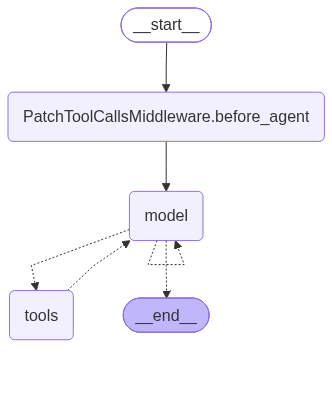

In [17]:
from deepagents import create_deep_agent

SYSTEM_PROMPT = f"""
You are the Firmable schema-mapping agent.

Your job is to map an external business dataset into the Firmable canonical ontology.

You have access to:
- the dataset profile
- the Firmable ontology
- search_docs() for authoritative documentation
- query_source() for inspecting the real dataset
- validate_mapping() for checking your proposed mapping

Workflow:
1. Inspect the supplied dataset profile and ontology.
2. Propose mappings only when supported by evidence.
3. If field semantics or codes are unclear, use search_docs().
4. If relationships or distributions are unclear, use query_source().
5. Produce a mapping configuration.
6. Call validate_mapping().
7. If validation fails, revise and validate again.
8. Do not stop until the mapping passes validation or you clearly explain why it cannot.

Important rules:
- Wrong mapping is worse than no mapping.
- Do not guess enum meanings.
- Low-confidence fields should remain unmapped.
- Transformation means source-specific logic only.
- General normalization and datatype/checksum validation are handled separately.
- Prefer direct mappings when possible.
- Use DuckDB SQL only when source-specific transformation is required.
- Field confidence is separate from source reliability and link confidence.
- Preserve provenance.
- Do not silently infer unsupported semantics.

Firmable ontology:

{ontology_text}
"""

agent = create_deep_agent(
    model=model,
    tools=[
        search_docs,
        query_source,
        validate_mapping,
    ],
    system_prompt=SYSTEM_PROMPT,
)

agent

In [18]:
agent_input = {
    "messages": [
        {
            "role": "user",
            "content": f"""
Map this dataset to the Firmable ontology.

Dataset profile:

{json.dumps(profile, indent=2)}
"""
        }
    ]
}

result = agent.invoke(agent_input)

In [19]:
result["messages"][-1].content

[{'id': 'rs_03917478fa1949d5006abb5adf535087d0b77121136a33d48e',
  'summary': [],
  'type': 'reasoning',
  'content': [],
  'encrypted_content': 'gAAAAABqu1rt2leqCAbL2eKJnPnq_t9A5lNIOdRO3NP0MviTZwSH-eHcXt5NKNu0LpjLlENeHFD5H9UfGYv2vAaW-FWCSs57hzNCy_aUp3m9Bj-zG0l0LiVvgnKYs9BQnCnQHw1Y_rvcmmMt-W2nLQaLvZnSb_7stOuT6soBAgV2Q53B4zQ-4ETw6QdeirOYtVkq9DFUX1-4IkcPbk1ozHd4EGsgTclhAx6vEpzym6MI-_bvLtLNz2cUU1skdbMZOnBwxttBf5wgp4A742pMx38Yx1r9cCXeEdCtXzY5sHITRayYs7kyRwxZrb51MlcojnF6_uJL7IfxZ68hdxEfyyWe6GeMhlJEL11Xf2BMftDuytdP52EHdQtTxZLJP0SBbalCihEyThaUGftbnE8R7icfAFdcpOW9ta8yo7nGidYj8HZa08wj2D1TLBDb743g07jxkxTe5v44CDnCModJYQh--3SpwW0P0qKY5g45zOLkKpIcD-lftKRwr0yM-Yji2XlcyT2uGKlxZhCJj-5ITvtVNmAA3Vnnfdekgb256glfSJXYVVRNGUpaNfDMFmmUvrUqxf3SdHBwKFGrDMIw9KilBVRjgGJYm181yAEwtrlfKi_nMzrZg5xzmSO9CPaH0oHMCWFcFgdSlAHkVRQB6i_TOtHXItin9uYvlM0LelPYfNSmSCmliXbssEypHtL8ffAnR_ds58zc6sydmrI0ZaXpFnmSXMIwBLqtVsg3IhXsvFkJzkgYLNKzUY6HCL_4UuEpt3PONLrsDRJe4yT53-tnPxKi-BGuREhok1XaNkFE4dWrt7SLsnQIBPYJEx16aONYnbuYXvdS88fN_NXPtg

 -->

# Second try 

In [20]:
import os
import re
import json
import time
import yaml
import duckdb
import pandas as pd

from pathlib import Path
from collections import defaultdict

from langchain_core.tools import tool
from deepagents import create_deep_agent
from tavily import TavilyClient

In [21]:
csv_path = Path(
    "data/ASIC_Company_Dataset/Company_Dataset_Current.csv"
)

csv_sql = str(csv_path).replace("'", "''")

con = duckdb.connect()

con.execute("DROP VIEW IF EXISTS source_data")
con.execute("DROP TABLE IF EXISTS source_data")

con.execute(f"""
    CREATE TABLE source_data AS
    SELECT *
    FROM read_csv_auto(
        '{csv_sql}',
        sample_size=-1
    )
""")

# Fixed validation set.
# Agent investigates source_data, but validation always uses this held sample.
con.execute("DROP TABLE IF EXISTS validation_sample")

con.execute("""
    CREATE TEMP TABLE validation_sample AS
    SELECT *
    FROM source_data
    USING SAMPLE 1000 ROWS
""")

print(
    "source:",
    con.execute("SELECT COUNT(*) FROM source_data").fetchone()[0]
)

print(
    "validation:",
    con.execute("SELECT COUNT(*) FROM validation_sample").fetchone()[0]
)

source: 4448915
validation: 1000


In [22]:
ontology = yaml.safe_load(ontology_text)

FIELD_SPECS = {}

for section in ["entity", "address", "observation", "confidence"]:
    for field, spec in ontology.get(section, {}).items():
        FIELD_SPECS[f"{section}.{field}"] = spec

VALID_TARGETS = set(FIELD_SPECS)

SOURCE_COLUMNS = {
    row[0]
    for row in con.execute("DESCRIBE source_data").fetchall()
}

SUPPORTED_TRANSFORMS = {
    "direct",
    "sql_expression",
    "constant",
}

REQUIRED_OBSERVATION_FIELDS = {
    "observation.source_id",
    "observation.source_record_id",
    "observation.observed_at",
    "observation.ingested_at",
    "observation.licence",
    "observation.extractor_version",
}


def is_null(value):
    if value is None:
        return True

    try:
        return bool(pd.isna(value))
    except Exception:
        return False


def valid_abn(value):
    if is_null(value):
        return False

    value = str(value).strip()

    if not re.fullmatch(r"\d{11}", value):
        return False

    digits = [int(x) for x in value]
    digits[0] -= 1

    weights = [10, 1, 3, 5, 7, 9, 11, 13, 15, 17, 19]

    return sum(
        d * w for d, w in zip(digits, weights)
    ) % 89 == 0


def valid_acn(value):
    if is_null(value):
        return False

    value = str(value).strip()

    if not re.fullmatch(r"\d{9}", value):
        return False

    digits = [int(x) for x in value]

    weights = [8, 7, 6, 5, 4, 3, 2, 1]

    total = sum(
        digits[i] * weights[i]
        for i in range(8)
    )

    check_digit = (10 - (total % 10)) % 10

    return digits[8] == check_digit


def canonical_value_valid(target, value):
    if is_null(value):
        return True

    if target == "entity.abn":
        return valid_abn(value)

    if target == "entity.acn":
        return valid_acn(value)

    spec = FIELD_SPECS.get(target, {})

    if isinstance(spec, dict):
        allowed_values = spec.get("values")

        if allowed_values:
            return str(value) in allowed_values

        field_type = spec.get("type")

        if field_type == "date":
            return not pd.isna(
                pd.to_datetime(value, errors="coerce")
            )

        if field_type == "datetime":
            return not pd.isna(
                pd.to_datetime(value, errors="coerce")
            )

        if field_type == "string":
            return bool(str(value).strip())

    return True

In [23]:
tavily = TavilyClient(
    api_key=os.environ["TAVILY_API_KEY"]
)


@tool
def search_docs(
    query: str,
    domains_csv: str = ""
) -> str:
    """
    Search authoritative documentation when source semantics are unclear.

    Prefer official publisher/government documentation.
    domains_csv may contain comma-separated preferred domains.
    """

    domains = [
        x.strip()
        for x in domains_csv.split(",")
        if x.strip()
    ]

    kwargs = {
        "query": query,
        "search_depth": "advanced",
        "max_results": 4,
    }

    if domains:
        kwargs["include_domains"] = domains

    result = tavily.search(**kwargs)

    compact = []

    for item in result.get("results", []):
        content = item.get("content") or ""

        compact.append({
            "title": item.get("title"),
            "url": item.get("url"),
            "content": content[:1200],
        })

    return json.dumps(
        compact,
        indent=2,
        ensure_ascii=False
    )

In [24]:
BLOCKED_SQL = re.compile(
    r"\b("
    r"insert|update|delete|drop|alter|create|"
    r"copy|attach|detach|install|load|pragma"
    r")\b",
    re.IGNORECASE
)


@tool
def query_source(sql: str) -> str:
    """
    Run a read-only SQL investigation against `source_data`.

    Useful for:
    - distributions
    - null patterns
    - field relationships
    - uniqueness
    - duplicates
    - samples

    Maximum 100 returned rows.
    """

    sql = sql.strip().rstrip(";")

    if not sql.lower().startswith(("select", "with")):
        return "ERROR: query must start with SELECT or WITH."

    if BLOCKED_SQL.search(sql):
        return "ERROR: mutating/admin SQL is not allowed."

    try:
        limited_sql = f"""
            SELECT *
            FROM (
                {sql}
            ) AS agent_query
            LIMIT 100
        """

        df = con.execute(limited_sql).df()

        return df.to_json(
            orient="records",
            indent=2,
            date_format="iso"
        )

    except Exception as e:
        return f"ERROR: {type(e).__name__}: {e}"

In [25]:
@tool
def validate_mapping(mapping_json: str) -> str:
    """
    Validate a candidate Firmable mapping on 1000 held validation rows.

    Checks:
    - ontology target exists
    - source fields exist
    - supported transformation type
    - confidence
    - SQL execution
    - canonical datatype / enums
    - ABN checksum
    - ACN checksum
    - required observation fields
    - source_record_id nulls / duplicates
    - suspicious identifier padding
    - accidental duplicate target mappings

    The mapping JSON may contain:

    {
      "mappings": [...],

      "runtime_fields": {
        "observation.ingested_at": "...",
        ...
      },

      "unmapped_fields": [...]
    }
    """

    try:
        config = json.loads(mapping_json)
    except Exception as e:
        return json.dumps({
            "valid": False,
            "errors": [f"Invalid JSON: {e}"],
            "warnings": []
        }, indent=2)

    mappings = config.get("mappings", [])

    runtime_fields_raw = config.get("runtime_fields", {})

    if isinstance(runtime_fields_raw, dict):
        runtime_fields = set(runtime_fields_raw)
    else:
        runtime_fields = set(runtime_fields_raw or [])

    errors = []
    warnings = []
    metrics = {}

    targets_seen = defaultdict(list)

    if not mappings:
        errors.append("No mappings supplied.")

    validation_rows = con.execute(
        "SELECT COUNT(*) FROM validation_sample"
    ).fetchone()[0]

    for i, mapping in enumerate(mappings):
        prefix = f"mapping[{i}]"

        target = mapping.get("target_field")
        source_fields = mapping.get("source_fields", [])
        confidence = mapping.get("confidence")
        transform = mapping.get("transformation", {})
        transform_type = transform.get("type")

        if not target:
            errors.append(
                f"{prefix}: target_field missing"
            )
            continue

        targets_seen[target].append(mapping)

        # -------------------------
        # Target exists
        # -------------------------

        if target not in VALID_TARGETS:
            errors.append(
                f"{prefix}: unknown target '{target}'"
            )

        # -------------------------
        # Source fields exist
        # -------------------------

        for field in source_fields:
            if field not in SOURCE_COLUMNS:
                errors.append(
                    f"{prefix}: source field "
                    f"'{field}' does not exist"
                )

        # -------------------------
        # Confidence
        # -------------------------

        if confidence is None:
            errors.append(
                f"{prefix}: confidence missing"
            )

        elif not isinstance(confidence, (int, float)):
            errors.append(
                f"{prefix}: confidence must be numeric"
            )

        elif not 0 <= confidence <= 1:
            errors.append(
                f"{prefix}: confidence outside [0,1]"
            )

        # -------------------------
        # Transformation type
        # -------------------------

        if transform_type not in SUPPORTED_TRANSFORMS:
            errors.append(
                f"{prefix}: unsupported transform "
                f"'{transform_type}'"
            )
            continue

        expression = transform.get("expression")

        # -------------------------
        # Prevent identifier invention
        # -------------------------

        if (
            target in {"entity.abn", "entity.acn"}
            and expression
            and re.search(
                r"\b(lpad|rpad)\s*\(",
                expression,
                re.IGNORECASE
            )
        ):
            errors.append(
                f"{prefix}: do not pad ABN/ACN values. "
                "Padding can invent identifiers."
            )

        # -------------------------
        # Constants
        # -------------------------

        if transform_type == "constant":
            if "value" not in transform:
                errors.append(
                    f"{prefix}: constant transform "
                    "requires 'value'"
                )
                continue

            values = pd.Series(
                [transform["value"]] * validation_rows
            )

        # -------------------------
        # SQL/direct
        # -------------------------

        else:
            if not expression:
                errors.append(
                    f"{prefix}: expression missing"
                )
                continue

            try:
                values = con.execute(f"""
                    SELECT
                        {expression} AS value
                    FROM validation_sample
                """).df()["value"]

            except Exception as e:
                errors.append(
                    f"{prefix}: transformation SQL failed: {e}"
                )
                continue

        # -------------------------
        # Actual data validation
        # -------------------------

        non_null = values[
            ~values.apply(is_null)
        ]

        invalid_values = [
            value
            for value in non_null
            if not canonical_value_valid(
                target,
                value
            )
        ]

        null_count = len(values) - len(non_null)
        invalid_count = len(invalid_values)

        metrics[target] = {
            "rows": len(values),

            "non_null_output": len(non_null),

            "null_rate": round(
                null_count / len(values),
                4
            ) if len(values) else None,

            "invalid_count": invalid_count,

            "invalid_rate": round(
                invalid_count / len(non_null),
                4
            ) if len(non_null) else 0,

            "invalid_examples": [
                str(x)
                for x in invalid_values[:5]
            ],
        }

        if invalid_count:
            warnings.append(
                f"{prefix}: {invalid_count} canonical-invalid "
                f"values found for {target}"
            )

        # -------------------------
        # Required observation fields
        # -------------------------

        if target in REQUIRED_OBSERVATION_FIELDS:
            if null_count:
                errors.append(
                    f"{prefix}: required field {target} "
                    f"produced {null_count} null values"
                )

        # -------------------------
        # Record ID must be unique
        # -------------------------

        if target == "observation.source_record_id":
            duplicated = int(non_null.duplicated().sum())

            metrics[target]["duplicate_count"] = duplicated

            if duplicated:
                errors.append(
                    f"{prefix}: source_record_id produced "
                    f"{duplicated} duplicate IDs in validation sample"
                )

    # --------------------------------
    # Duplicate target handling
    # --------------------------------

    for target, target_mappings in targets_seen.items():
        if len(target_mappings) <= 1:
            continue

        explicitly_separate = all(
            m.get("emit_separate_observation") is True
            for m in target_mappings
        )

        if not explicitly_separate:
            errors.append(
                f"Multiple mappings produce '{target}'. "
                "Either select one mapping or explicitly set "
                "emit_separate_observation=true with supporting evidence."
            )

        else:
            warnings.append(
                f"Multiple mappings intentionally emit separate "
                f"observations for {target}."
            )

    # --------------------------------
    # Required observation coverage
    # --------------------------------

    mapped_targets = set(targets_seen)

    missing_required = (
        REQUIRED_OBSERVATION_FIELDS
        - mapped_targets
        - runtime_fields
    )

    for target in sorted(missing_required):
        errors.append(
            f"Required field '{target}' is neither mapped "
            "nor declared as runtime-generated."
        )

    return json.dumps({
        "valid": len(errors) == 0,
        "errors": errors,
        "warnings": warnings,
        "field_metrics": metrics,
        "validation_rows": validation_rows,
    }, indent=2, default=str)

In [26]:
SYSTEM_PROMPT = f"""
You are the Firmable source-onboarding schema-mapping agent.

Your task is to produce a safe, machine-readable mapping from an
external dataset into the Firmable canonical ontology.

You have these tools:

1. search_docs
   Search authoritative documentation when field semantics or codes
   cannot be safely established from the dataset itself.

2. query_source
   Investigate the real source data using read-only DuckDB SQL.

3. validate_mapping
   Test the proposed mapping against held validation records and
   Firmable canonical constraints.


WORKFLOW

1. Inspect the supplied profile and metadata.

2. Identify obvious mappings.

3. Identify uncertain semantics.

4. If semantics are unclear:
   - search official publisher/government documentation.
   - prefer authoritative sources over third-party explanations.

5. If relationships between fields are unclear:
   - investigate them with query_source.
   Examples:
     - whether two name fields duplicate each other
     - uniqueness of candidate record IDs
     - status distributions
     - null relationships

6. Propose a mapping configuration.

7. Call validate_mapping.

8. If validation reports errors:
   investigate the cause, revise the mapping, and validate again.

9. Stop only when:
   - validation passes, or
   - you clearly identify an unresolved issue that prevents a safe mapping.


IMPORTANT MAPPING RULES

- Wrong mapping is worse than no mapping.
- Never guess enum/code meanings.
- Leave unsupported or low-confidence fields unmapped.

- Mapping identifies semantic correspondence.
- Transformation contains SOURCE-SPECIFIC logic only.

General normalization is NOT mapping logic.
It is handled downstream by the generic extraction engine.

Examples of downstream normalization/validation:
- whitespace normalization
- date normalization
- datatype conversion
- enum validation
- ABN checksum
- ACN checksum

Do NOT duplicate those rules unnecessarily inside mapping SQL.

Source-specific missing-value rules ARE allowed.
Example:
ABN = 0 may be converted to NULL if documentation/data supports it.

NEVER invent an identifier.
In particular:
- never left-pad or right-pad malformed ABNs or ACNs
- never manufacture missing digits

Prefer:
direct
over sql_expression
when no source-specific transformation is required.

Use transformation type "constant" for dataset-level constants.

Consider dataset-level semantics.
For example, if authoritative metadata clearly establishes that every
record is a company, a constant entity.entity_type mapping may be valid.

Multiple source fields mapping to the same canonical target require
special care.

Do not emit duplicate canonical observations accidentally.

If multiple mappings intentionally create separate observations, each
mapping must include:

    "emit_separate_observation": true

and the decision must be supported by source semantics.

For source_record_id:
- prefer a stable declared source key when available and unique
- verify uniqueness
- otherwise construct a deterministic fingerprint
- do not rely on unstable row ordering unless unavoidable and documented

For observation.source_id:
prefer the resource identifier for the specific source resource when
available.

Do not invent observation.observed_at.
If it must be supplied at runtime from trustworthy resource metadata,
declare that in runtime_fields.

observation.ingested_at should normally be runtime generated.

observation.extractor_version should normally be runtime generated.


FINAL CONFIG SHAPE

Return exactly one JSON object:

{{
  "mappings": [
    {{
      "source_fields": ["field"],
      "target_field": "entity.some_field",
      "transformation": {{
        "type": "direct | sql_expression | constant",
        "expression": "SQL expression when applicable",
        "value": "constant when applicable"
      }},
      "confidence": 0.0,
      "derivation_level": "L0 | L1 | L2 | L3 | L4",
      "reason": "short explanation"
    }}
  ],

  "runtime_fields": {{
    "observation.ingested_at": "generated at ingestion time"
  }},

  "unmapped_fields": [
    {{
      "source_field": "field",
      "reason": "why it is intentionally unmapped"
    }}
  ],

  "research_notes": [
    {{
      "finding": "what was established",
      "source_url": "authoritative URL"
    }}
  ]
}}

Do not return Markdown around the final JSON.

FIRMABLE ONTOLOGY:

{ontology_text}
"""

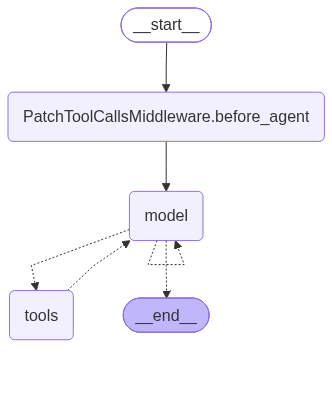

In [27]:
agent = create_deep_agent(
    model=model,
    tools=[
        search_docs,
        query_source,
        validate_mapping,
    ],
    system_prompt=SYSTEM_PROMPT,
)

agent

In [28]:
agent_input = {
    "messages": [
        {
            "role": "user",
            "content": f"""
Onboard this dataset into the Firmable ontology.

Investigate only when necessary.

Normally use no more than:
- 2 documentation searches
- 4 data investigation queries

You MUST validate the final mapping using validate_mapping.

Dataset profile:

{json.dumps(profile, indent=2, default=str)}
"""
        }
    ]
}

In [29]:
from langchain_core.messages import AIMessage, ToolMessage


def message_text(message):
    content = message.content

    if isinstance(content, str):
        return content

    if isinstance(content, list):
        parts = []

        for block in content:
            if isinstance(block, dict):
                text = block.get("text")

                if text:
                    parts.append(text)

        return "\n".join(parts)

    return str(content)


start_time = time.perf_counter()

result = None
previous_message_count = 0

for state in agent.stream(
    agent_input,
    config={
        "recursion_limit": 15
    },
    stream_mode="values"
):
    result = state

    messages = state.get("messages", [])

    if len(messages) == previous_message_count:
        continue

    previous_message_count = len(messages)

    msg = messages[-1]

    if isinstance(msg, AIMessage):
        if msg.tool_calls:
            print("\nMODEL → TOOLS")

            for call in msg.tool_calls:
                print(
                    " ",
                    call["name"],
                    call.get("args", {})
                )

        else:
            text = message_text(msg)

            if text:
                print("\nMODEL")
                print(text[:2000])

    elif isinstance(msg, ToolMessage):
        print(
            f"\nTOOL → {msg.name}"
        )

        print(
            message_text(msg)[:1500]
        )

elapsed_seconds = time.perf_counter() - start_time

print(
    f"\nWall clock: {elapsed_seconds:.2f} seconds"
)


MODEL → TOOLS
  search_docs {'query': 'site:asic.gov.au Company Dataset help file Current Name Indicator status codes REGD DRGD SOFF EXAD ASIC company dataset', 'domains_csv': 'asic.gov.au'}
  query_source {'sql': 'SELECT COUNT(*) AS rows, COUNT(DISTINCT "ACN") AS distinct_acn, COUNT(DISTINCT "ACN" || \'|\' || RTRIM("Company Name")) AS acn_name_pairs, SUM(CASE WHEN "Current Name Indicator" = \'Y\' THEN 1 ELSE 0 END) AS current_flag_y, SUM(CASE WHEN "Current Name Indicator" IS NULL THEN 1 ELSE 0 END) AS current_flag_null, SUM(CASE WHEN "Current Name Indicator" NOT IN (\'Y\') AND "Current Name Indicator" IS NOT NULL THEN 1 ELSE 0 END) AS other_flag FROM source_data'}
  query_source {'sql': 'SELECT "Status", COUNT(*) AS n, COUNT("Date of Deregistration") AS dereg_date_n, MIN("Date of Deregistration") AS min_dereg, MAX("Date of Deregistration") AS max_dereg FROM source_data GROUP BY 1 ORDER BY n DESC'}
  query_source {'sql': 'SELECT COUNT(*) AS total, SUM(CASE WHEN ABN = 0 THEN 1 ELSE 0 E

GraphRecursionError: Recursion limit of 15 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

In [ ]:
messages = result["messages"]

model_calls = 0
tool_calls = 0

input_tokens = 0
output_tokens = 0
total_tokens = 0

for msg in messages:
    if isinstance(msg, AIMessage):
        model_calls += 1

        tool_calls += len(
            msg.tool_calls or []
        )

        usage = getattr(
            msg,
            "usage_metadata",
            None
        )

        if usage:
            input_tokens += usage.get(
                "input_tokens", 0
            )

            output_tokens += usage.get(
                "output_tokens", 0
            )

            total_tokens += usage.get(
                "total_tokens", 0
            )

run_metrics = {
    "model_calls": model_calls,
    "tool_calls": tool_calls,
    "input_tokens": input_tokens,
    "output_tokens": output_tokens,
    "total_tokens": total_tokens,
    "wall_clock_seconds": round(
        elapsed_seconds,
        2
    ),
}

run_metrics

## new try

In [35]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "openai:gpt-6-luna"
)



model

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.3', 'langchain-openai': '1.6.6'}}, profile={'name': 'GPT-6 Luna', 'release_date': '2026-09-22', 'last_updated': '2026-09-22', 'open_weights': False, 'max_input_tokens': 1050000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True, 'reasoning_effort_levels': ['none', 'low', 'medium', 'high', 'xhigh', 'max'], 'reasoning_effort_default': 'medium'}, client=<openai.resources.chat.completions.completions.Completions object at 0x11f3d18b0>, async_client=<openai.resources.chat.completions.comple

In [31]:
import threading

duckdb_lock = threading.Lock()

BLOCKED_SQL = re.compile(
    r"\b("
    r"insert|update|delete|drop|alter|create|"
    r"copy|attach|detach|install|load|pragma"
    r")\b",
    re.IGNORECASE
)


@tool
def query_source(sql: str) -> str:
    """
    Run a read-only SQL investigation against source_data.

    Useful for:
    - distributions
    - null patterns
    - field relationships
    - uniqueness
    - duplicates
    - samples

    Maximum 100 returned rows.
    """

    sql = sql.strip().rstrip(";")

    if not sql.lower().startswith(("select", "with")):
        return "ERROR: query must start with SELECT or WITH."

    if BLOCKED_SQL.search(sql):
        return "ERROR: mutating/admin SQL is not allowed."

    try:
        limited_sql = f"""
            SELECT *
            FROM (
                {sql}
            ) AS agent_query
            LIMIT 100
        """

        with duckdb_lock:
            df = con.execute(limited_sql).df()

        return df.to_json(
            orient="records",
            indent=2,
            date_format="iso"
        )

    except Exception as e:
        return f"ERROR: {type(e).__name__}: {e}"

In [32]:
def quote_identifier(name):
    return '"' + str(name).replace('"', '""') + '"'


@tool
def validate_mapping(mapping_json: str) -> str:
    """
    Validate a candidate Firmable mapping on held validation rows.
    """

    try:
        config = json.loads(mapping_json)
    except Exception as e:
        return json.dumps({
            "valid": False,
            "errors": [f"Invalid JSON: {e}"],
            "warnings": []
        }, indent=2)

    mappings = config.get("mappings", [])
    runtime_fields_raw = config.get("runtime_fields", {})

    runtime_fields = (
        set(runtime_fields_raw)
        if isinstance(runtime_fields_raw, dict)
        else set(runtime_fields_raw or [])
    )

    errors = []
    warnings = []
    metrics = {}

    targets_seen = defaultdict(list)

    if not mappings:
        errors.append("No mappings supplied.")

    with duckdb_lock:
        validation_rows = con.execute(
            "SELECT COUNT(*) FROM validation_sample"
        ).fetchone()[0]

    for i, mapping in enumerate(mappings):
        prefix = f"mapping[{i}]"

        target = mapping.get("target_field")
        source_fields = mapping.get("source_fields", [])
        confidence = mapping.get("confidence")
        transform = mapping.get("transformation", {})
        transform_type = transform.get("type")

        if not target:
            errors.append(f"{prefix}: target_field missing")
            continue

        targets_seen[target].append(mapping)

        if target not in VALID_TARGETS:
            errors.append(
                f"{prefix}: unknown target '{target}'"
            )

        for field in source_fields:
            if field not in SOURCE_COLUMNS:
                errors.append(
                    f"{prefix}: source field '{field}' does not exist"
                )

        if confidence is None:
            errors.append(f"{prefix}: confidence missing")

        elif not isinstance(confidence, (int, float)):
            errors.append(
                f"{prefix}: confidence must be numeric"
            )

        elif not 0 <= confidence <= 1:
            errors.append(
                f"{prefix}: confidence outside [0,1]"
            )

        if transform_type not in SUPPORTED_TRANSFORMS:
            errors.append(
                f"{prefix}: unsupported transform '{transform_type}'"
            )
            continue

        # ------------------------
        # DIRECT
        # ------------------------

        if transform_type == "direct":
            if len(source_fields) != 1:
                errors.append(
                    f"{prefix}: direct transformation requires exactly one source field"
                )
                continue

            expression = quote_identifier(source_fields[0])

        # ------------------------
        # SQL EXPRESSION
        # ------------------------

        elif transform_type == "sql_expression":
            expression = transform.get("expression")

            if not expression:
                errors.append(
                    f"{prefix}: sql_expression requires expression"
                )
                continue

        # ------------------------
        # CONSTANT
        # ------------------------

        elif transform_type == "constant":
            if "value" not in transform:
                errors.append(
                    f"{prefix}: constant transformation requires value"
                )
                continue

            values = pd.Series(
                [transform["value"]] * validation_rows
            )

        # ------------------------
        # IDENTIFIER SAFETY
        # ------------------------

        if transform_type != "constant":
            if (
                target in {"entity.abn", "entity.acn"}
                and re.search(
                    r"\b(lpad|rpad)\s*\(",
                    expression,
                    re.IGNORECASE
                )
            ):
                errors.append(
                    f"{prefix}: do not pad ABN/ACN values; "
                    "padding can invent identifiers"
                )
                continue

            try:
                with duckdb_lock:
                    values = con.execute(f"""
                        SELECT
                            {expression} AS value
                        FROM validation_sample
                    """).df()["value"]

            except Exception as e:
                errors.append(
                    f"{prefix}: transformation SQL failed: {e}"
                )
                continue

        # ------------------------
        # CANONICAL VALIDATION
        # ------------------------

        non_null = values[
            ~values.apply(is_null)
        ]

        invalid_values = [
            value
            for value in non_null
            if not canonical_value_valid(
                target,
                value
            )
        ]

        null_count = len(values) - len(non_null)
        invalid_count = len(invalid_values)

        metrics[target] = {
            "rows": len(values),
            "non_null_output": len(non_null),
            "null_rate": round(
                null_count / len(values), 4
            ) if len(values) else None,
            "invalid_count": invalid_count,
            "invalid_rate": round(
                invalid_count / len(non_null), 4
            ) if len(non_null) else 0,
            "invalid_examples": [
                str(x)
                for x in invalid_values[:5]
            ],
        }

        if invalid_count:
            warnings.append(
                f"{prefix}: {invalid_count} canonical-invalid "
                f"values for {target}"
            )

        if target in REQUIRED_OBSERVATION_FIELDS:
            if null_count:
                errors.append(
                    f"{prefix}: required field {target} "
                    f"produced {null_count} null values"
                )

        if target == "observation.source_record_id":
            duplicated = int(
                non_null.duplicated().sum()
            )

            metrics[target]["duplicate_count"] = duplicated

            if duplicated:
                errors.append(
                    f"{prefix}: source_record_id produced "
                    f"{duplicated} duplicate IDs"
                )

    # ------------------------
    # DUPLICATE TARGETS
    # ------------------------

    for target, target_mappings in targets_seen.items():
        if len(target_mappings) <= 1:
            continue

        explicitly_separate = all(
            m.get("emit_separate_observation") is True
            for m in target_mappings
        )

        if not explicitly_separate:
            errors.append(
                f"Multiple mappings produce '{target}'. "
                "Select one or explicitly set "
                "emit_separate_observation=true."
            )

    # ------------------------
    # REQUIRED OBSERVATION FIELDS
    # ------------------------

    mapped_targets = set(targets_seen)

    missing_required = (
        REQUIRED_OBSERVATION_FIELDS
        - mapped_targets
        - runtime_fields
    )

    for target in sorted(missing_required):
        errors.append(
            f"Required field '{target}' is neither mapped "
            "nor declared runtime-generated."
        )

    return json.dumps({
        "valid": len(errors) == 0,
        "errors": errors,
        "warnings": warnings,
        "field_metrics": metrics,
        "validation_rows": validation_rows,
    }, indent=2, default=str)

In [33]:
SYSTEM_PROMPT = f"""
You are the Firmable source-onboarding schema-mapping agent.

Your task is to produce a safe machine-readable mapping from an
external dataset into the Firmable canonical ontology.

TOOLS

search_docs:
Use authoritative documentation when source semantics or codes
cannot be safely understood from the dataset.

query_source:
Use read-only DuckDB SQL to investigate field relationships,
distributions, uniqueness and unusual values.

validate_mapping:
Validate the proposed mapping against held-out records and
Firmable canonical constraints.


WORKFLOW

1. Inspect the supplied profile and metadata.

2. Identify obvious mappings.

3. Identify uncertain semantics.

4. Search authoritative documentation only when needed.

5. Query the source only when relationships or data behaviour
   cannot be determined from the profile.

6. Propose a mapping.

7. Call validate_mapping.

8. If validation fails:
   understand the error,
   revise the mapping,
   validate again.

9. Once validation returns valid=true:
   STOP USING TOOLS.
   Return the final JSON configuration immediately.


RULES

Wrong mapping is worse than no mapping.

Never guess enum or code meanings.

Leave unsupported or low-confidence fields unmapped.

Mapping determines semantic correspondence.

Transformation contains source-specific logic only.

General normalization and canonical validation are handled downstream.

Examples handled downstream:
- whitespace normalization
- date normalization
- datatype conversion
- enum validation
- ABN checksum
- ACN checksum


TRANSFORMATION TYPES

direct:
Use when exactly one source field maps directly to one target.
Do NOT provide an SQL expression.
The extraction engine automatically selects and quotes the source field.

Example:

{{
  "source_fields": ["Company Name"],
  "target_field": "entity.legal_name",
  "transformation": {{
    "type": "direct"
  }}
}}


sql_expression:
Use only when source-specific transformation logic is required.

Example:

CASE WHEN ABN = 0
     THEN NULL
     ELSE CAST(ABN AS VARCHAR)
END


constant:
Use for values established from dataset-level semantics or metadata.

Example:

entity.entity_type = company


IDENTIFIER SAFETY

Never invent identifiers.

Never pad malformed ABNs or ACNs.

Do not use LPAD or RPAD to manufacture identifier length.


MULTIPLE TARGET MAPPINGS

Do not accidentally map multiple source fields to the same canonical
target.

If multiple mappings intentionally create separate observations,
each must contain:

"emit_separate_observation": true

and must be justified by authoritative source semantics.


SOURCE RECORD ID

Prefer a stable declared source key if one exists.

Verify uniqueness.

Otherwise create a deterministic fingerprint.

Do not rely on row position unless unavoidable.


OBSERVATION FIELDS

Use the specific resource identifier as observation.source_id
when available.

Do not invent observation.observed_at.

observation.ingested_at should normally be runtime generated.

observation.extractor_version should normally be runtime generated.


FINAL OUTPUT

Return raw JSON only.

{{
  "mappings": [
    {{
      "source_fields": ["field"],
      "target_field": "entity.some_field",
      "transformation": {{
        "type": "direct"
      }},
      "confidence": 0.99,
      "derivation_level": "L0",
      "reason": "short explanation"
    }}
  ],

  "runtime_fields": {{
    "observation.ingested_at": "generated at ingestion time"
  }},

  "unmapped_fields": [
    {{
      "source_field": "field",
      "reason": "why intentionally unmapped"
    }}
  ],

  "research_notes": [
    {{
      "finding": "finding",
      "source_url": "authoritative URL"
    }}
  ]
}}

FIRMABLE ONTOLOGY:

{ontology_text}
"""

In [36]:
agent = create_deep_agent(
    model=model,
    tools=[
        search_docs,
        query_source,
        validate_mapping,
    ],
    system_prompt=SYSTEM_PROMPT,
)


start_time = time.perf_counter()

result = None
previous_message_count = 0

for state in agent.stream(
    agent_input,
    config={
        "recursion_limit": 30
    },
    stream_mode="values"
):
    result = state

    messages = state.get("messages", [])

    if len(messages) == previous_message_count:
        continue

    previous_message_count = len(messages)

    msg = messages[-1]

    if isinstance(msg, AIMessage):

        if msg.tool_calls:

            print("\nMODEL → TOOLS")

            for call in msg.tool_calls:
                print(
                    call["name"],
                    call.get("args", {})
                )

        else:

            text = message_text(msg)

            if text:
                print("\nMODEL")
                print(text[:3000])

    elif isinstance(msg, ToolMessage):

        print(
            f"\nTOOL → {msg.name}"
        )

        print(
            message_text(msg)[:2000]
        )


elapsed_seconds = (
    time.perf_counter()
    - start_time
)

print(
    f"\nWall clock: {elapsed_seconds:.2f} seconds"
)


MODEL → TOOLS
query_source {'sql': 'SELECT length(CAST(ABN AS VARCHAR)) AS abn_len, COUNT(*) AS n FROM source GROUP BY 1 ORDER BY 1'}
query_source {'sql': 'SELECT COUNT(*) AS rows, COUNT(DISTINCT ACN) AS distinct_acn, COUNT(DISTINCT concat(ACN, \'|\', "Company Name")) AS distinct_acn_name, COUNT(*) - COUNT(DISTINCT concat(ACN, \'|\', "Company Name")) AS duplicate_acn_name FROM source'}
query_source {'sql': 'SELECT Status, COUNT(*) AS n FROM source GROUP BY Status ORDER BY n DESC'}

TOOL → query_source
ERROR: CatalogException: Catalog Error: Table with name source does not exist!
Did you mean "source_data"?

LINE 4:                 SELECT Status, COUNT(*) AS n FROM source GROUP BY Status ORDER BY n DESC
                                                          ^

MODEL → TOOLS
query_source {'sql': 'SELECT length(CAST(ABN AS VARCHAR)) AS abn_len, COUNT(*) AS n FROM source_data GROUP BY 1 ORDER BY 1'}
query_source {'sql': 'SELECT COUNT(*) AS rows, COUNT(DISTINCT ACN) AS distinct_acn, COU